## Atividade 1

Condições de contorno:
u(0) = 0.10000000
u(1) = 0.27182818


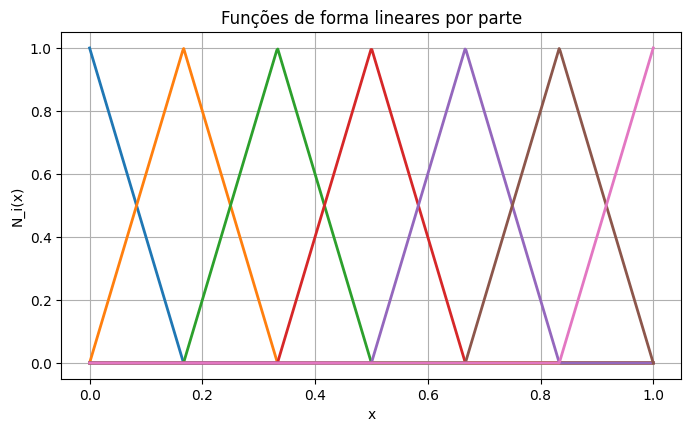

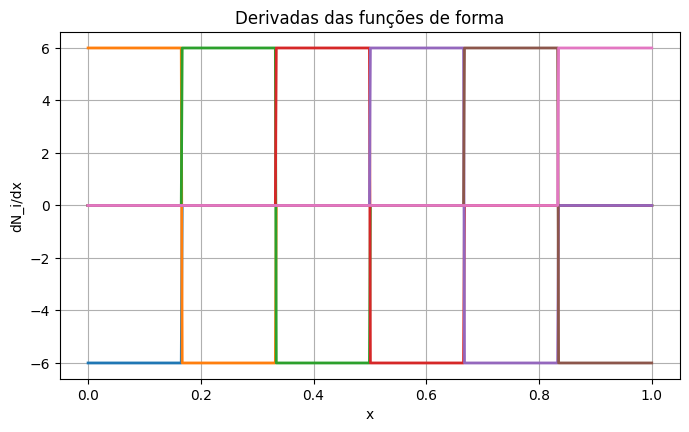

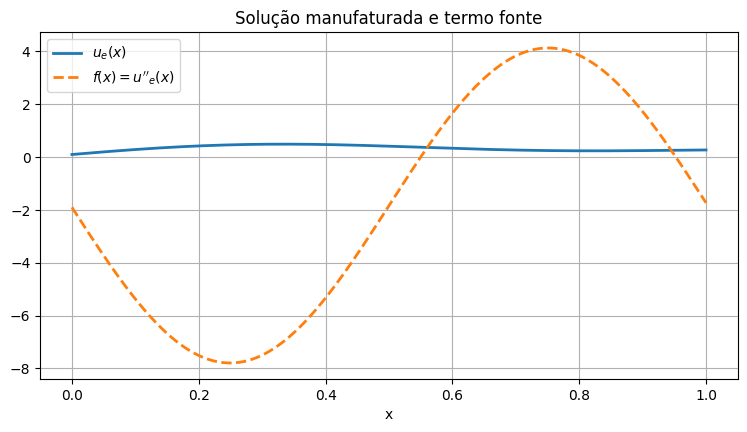


n = 6
cond(K) = 13.928203230275509

Comparação para n = 6
RMSE FEM = 1.14445513e-02
RMSE FDM = 6.77256372e-03


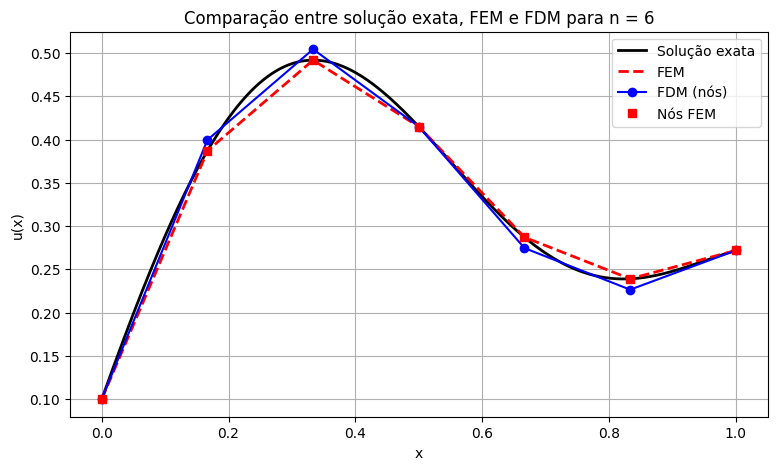


n = 4
cond(K) = 5.8284271247461925

n = 8
cond(K) = 25.274142369088146

n = 16
cond(K) = 103.08686891981728

n = 32
cond(K) = 414.3450622319015

Tabela de erros:
n     RMSE_FEM         RMSE_FDM
4     2.51308960e-02   1.66042666e-02
8     6.49289340e-03   3.70218557e-03
16    1.63670357e-03   9.01032391e-04
32    4.10023825e-04   2.23769822e-04

Taxas observadas de convergência:
n     rate_FEM    rate_FDM
4            -           -
8       1.9525      2.1651
16      1.9881      2.0387
32      1.9970      2.0096


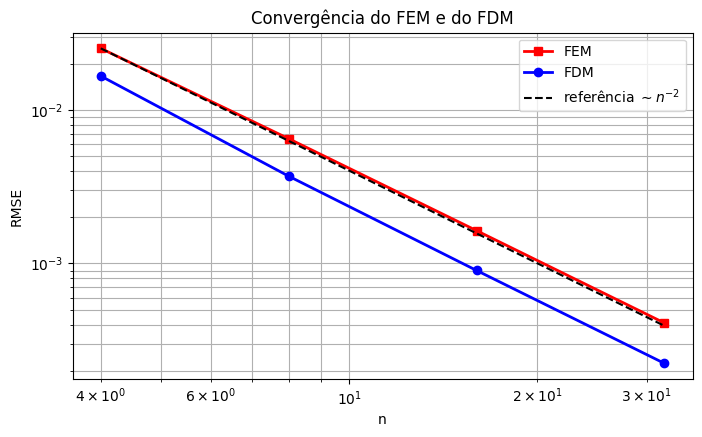

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import math

# Solução manufaturada

def ue(x):
    return x*(1.0 - x) + 0.15*np.sin(2.0*np.pi*x) + 0.10*np.exp(x)

def f(x):
    # f = u_e,xx
    return -2.0 - 0.15*(2.0*np.pi)**2*np.sin(2.0*np.pi*x) + 0.10*np.exp(x)

u_left = float(ue(0.0))
u_right = float(ue(1.0))

print("Condições de contorno:")
print(f"u(0) = {u_left:.8f}")
print(f"u(1) = {u_right:.8f}")

# Funções de forma

def N(xp, xi, i):
    last_i = len(xi) - 1
    if (i == 0 and xp <= xi[1]):
        y = (xi[1] - xp) / (xi[1] - xi[0])
    elif (i == last_i and xp >= xi[last_i - 1]):
        y = (xp - xi[last_i - 1]) / (xi[last_i] - xi[last_i - 1])
    elif (xp >= xi[i] and xp <= xi[i + 1]):
        y = (xi[i + 1] - xp) / (xi[i + 1] - xi[i])
    elif (xp <= xi[i] and xp >= xi[i - 1]):
        y = (xp - xi[i - 1]) / (xi[i] - xi[i - 1])
    else:
        y = 0.0
    return y

def dNdx(xp, xi, i):
    last_i = len(xi) - 1
    if (i == 0 and xp <= xi[1]):
        y = (-1.0) / (xi[1] - xi[0])
    elif (i == last_i and xp >= xi[last_i - 1]):
        y = (1.0) / (xi[last_i] - xi[last_i - 1])
    elif (xp >= xi[i] and xp <= xi[i + 1]):
        y = (-1.0) / (xi[i + 1] - xi[i])
    elif (xp <= xi[i] and xp >= xi[i - 1]):
        y = (1.0) / (xi[i] - xi[i - 1])
    else:
        y = 0.0
    return y

# Solver FEM
#    Problema da atividade:
#         u_xx = f(x)
#         u(0) = ue(0)
#         u(1) = ue(1)
#
#    Forma fraca:
#         ∫ w_x u_x dx = - ∫ w f dx

def solve_fem(n_elem):
    xi = np.linspace(0.0, 1.0, n_elem + 1)
    n_nodes = len(xi)

    # nós internos = incógnitas livres
    free_nodes = list(range(1, n_nodes - 1))
    n_free = len(free_nodes)

    K = np.zeros((n_free, n_free))
    F = np.zeros(n_free)

    # pontos onde as funções mudam de expressão
    breakpoints = xi[1:-1]

    def innerprod_a(xp, xi, a, b):
        return dNdx(xp, xi, a) * dNdx(xp, xi, b)

    def innerprod_f(xp, xi, a):
        return N(xp, xi, a) * f(xp)

    for ia, a in enumerate(free_nodes):
        for ib, b in enumerate(free_nodes):
            K[ia, ib] = quad(
                innerprod_a, 0.0, 1.0,
                args=(xi, a, b),
                points=breakpoints,
                limit=200
            )[0]

        F[ia] = (
            - quad(
                innerprod_f, 0.0, 1.0,
                args=(xi, a),
                points=breakpoints,
                limit=200
            )[0]
            - u_left * quad(
                innerprod_a, 0.0, 1.0,
                args=(xi, a, 0),
                points=breakpoints,
                limit=200
            )[0]
            - u_right * quad(
                innerprod_a, 0.0, 1.0,
                args=(xi, a, n_nodes - 1),
                points=breakpoints,
                limit=200
            )[0]
        )

    # diagnóstico opcional
    print(f"\nn = {n_elem}")
    print("cond(K) =", np.linalg.cond(K))

    d_internal = np.linalg.solve(K, F)

    d = np.zeros(n_nodes)
    d[0] = u_left
    d[-1] = u_right
    d[1:-1] = d_internal

    return xi, d

# Avaliar solução FEM em qualquer ponto

def evaluate_fem(xp, xi, d):
    val = 0.0
    for j in range(len(xi)):
        val += N(xp, xi, j) * d[j]
    return val

# Solver FDM
#       (u_{j-1} - 2u_j + u_{j+1}) / h^2 = f(x_j)

def solve_fdm(n_elem):
    x = np.linspace(0.0, 1.0, n_elem + 1)
    h = x[1] - x[0]
    n_int = n_elem - 1

    A = np.zeros((n_int, n_int))
    b = np.zeros(n_int)

    for j in range(n_int):
        if j > 0:
            A[j, j - 1] = 1.0
        A[j, j] = -2.0
        if j < n_int - 1:
            A[j, j + 1] = 1.0

        b[j] = h**2 * f(x[j + 1])

    # incorporar as condições de contorno
    b[0] -= u_left
    b[-1] -= u_right

    u = np.zeros(n_elem + 1)
    u[0] = u_left
    u[-1] = u_right
    u[1:-1] = np.linalg.solve(A, b)

    return x, u

# Erro médio quadrático (RMSE)

def rmse_fem(xi, d, n_dense=2000):
    x_dense = np.linspace(0.0, 1.0, n_dense)
    u_num = np.array([evaluate_fem(xp, xi, d) for xp in x_dense])
    u_ex = ue(x_dense)
    return np.sqrt(np.mean((u_num - u_ex)**2))

def rmse_fdm(x, u, n_dense=2000):
    x_dense = np.linspace(0.0, 1.0, n_dense)
    u_num = np.interp(x_dense, x, u)
    u_ex = ue(x_dense)
    return np.sqrt(np.mean((u_num - u_ex)**2))

# Plot das funções N_i e dN_i/dx

n_plot_shape = 6
xi_shape = np.linspace(0.0, 1.0, n_plot_shape + 1)
x_plot = np.linspace(0.0, 1.0, 600)

plt.figure(figsize=(8, 4.5))
for j in range(len(xi_shape)):
    Nj = np.array([N(xp, xi_shape, j) for xp in x_plot])
    plt.plot(x_plot, Nj, linewidth=2)
plt.grid(True)
plt.xlabel("x")
plt.ylabel("N_i(x)")
plt.title("Funções de forma lineares por parte")
plt.show()

plt.figure(figsize=(8, 4.5))
for j in range(len(xi_shape)):
    dNj = np.array([dNdx(xp, xi_shape, j) for xp in x_plot])
    plt.plot(x_plot, dNj, linewidth=2)
plt.grid(True)
plt.xlabel("x")
plt.ylabel("dN_i/dx")
plt.title("Derivadas das funções de forma")
plt.show()

# Solução manufaturada e f(x)

plt.figure(figsize=(9, 4.5))
plt.plot(x_plot, ue(x_plot), label=r"$u_e(x)$", linewidth=2)
plt.plot(x_plot, f(x_plot), "--", label=r"$f(x)=u''_e(x)$", linewidth=2)
plt.grid(True)
plt.xlabel("x")
plt.title("Solução manufaturada e termo fonte")
plt.legend()
plt.show()

# Comparação para n = 6

n = 6

xi_fem, d_fem = solve_fem(n)
x_fdm, u_fdm = solve_fdm(n)

u_fem_plot = np.array([evaluate_fem(xp, xi_fem, d_fem) for xp in x_plot])

err_fem_6 = rmse_fem(xi_fem, d_fem)
err_fdm_6 = rmse_fdm(x_fdm, u_fdm)

print(f"\nComparação para n = {n}")
print(f"RMSE FEM = {err_fem_6:.8e}")
print(f"RMSE FDM = {err_fdm_6:.8e}")

plt.figure(figsize=(9, 5))
plt.plot(x_plot, ue(x_plot), "k", linewidth=2, label="Solução exata")
plt.plot(x_plot, u_fem_plot, "r--", linewidth=2, label="FEM")
plt.plot(x_fdm, u_fdm, "bo-", linewidth=1.5, label="FDM (nós)")
plt.plot(xi_fem, d_fem, "rs", label="Nós FEM")
plt.grid(True)
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Comparação entre solução exata, FEM e FDM para n = 6")
plt.legend()
plt.show()

# Convergência para n = 4, 8, 16, 32

n_values = [4, 8, 16, 32]
errors_fem = []
errors_fdm = []

for n in n_values:
    xi_fem, d_fem = solve_fem(n)
    x_fdm, u_fdm = solve_fdm(n)

    errors_fem.append(rmse_fem(xi_fem, d_fem))
    errors_fdm.append(rmse_fdm(x_fdm, u_fdm))

errors_fem = np.array(errors_fem)
errors_fdm = np.array(errors_fdm)

print("\nTabela de erros:")
print("n     RMSE_FEM         RMSE_FDM")
for n, ef, ed in zip(n_values, errors_fem, errors_fdm):
    print(f"{n:<5d} {ef:.8e}   {ed:.8e}")

# taxas observadas
rates_fem = [np.nan]
rates_fdm = [np.nan]
for i in range(1, len(n_values)):
    rates_fem.append(np.log(errors_fem[i-1] / errors_fem[i]) / np.log(2))
    rates_fdm.append(np.log(errors_fdm[i-1] / errors_fdm[i]) / np.log(2))

print("\nTaxas observadas de convergência:")
print("n     rate_FEM    rate_FDM")
for n, rf, rd in zip(n_values, rates_fem, rates_fdm):
    if np.isnan(rf):
        print(f"{n:<5d} {'-':>8}    {'-':>8}")
    else:
        print(f"{n:<5d} {rf:8.4f}    {rd:8.4f}")

plt.figure(figsize=(8, 4.5))
plt.loglog(n_values, errors_fem, "rs-", linewidth=2, label="FEM")
plt.loglog(n_values, errors_fdm, "bo-", linewidth=2, label="FDM")

ref = errors_fem[0] * (np.array(n_values) / n_values[0])**(-2)
plt.loglog(n_values, ref, "k--", label=r"referência $\sim n^{-2}$")

plt.grid(True, which="both")
plt.xlabel("n")
plt.ylabel("RMSE")
plt.title("Convergência do FEM e do FDM")
plt.legend()
plt.show()

## Atividade 2

Nó central = 0.5

Erro máximo FEM vs exata = 3.552713678800501e-15
Erro máximo FDM vs exata = 7.105427357601002e-15
Erro máximo FEM vs FDM   = 5.329070518200751e-15


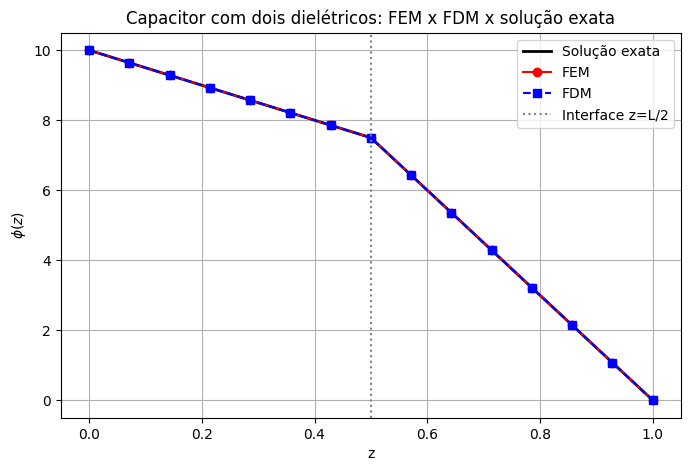

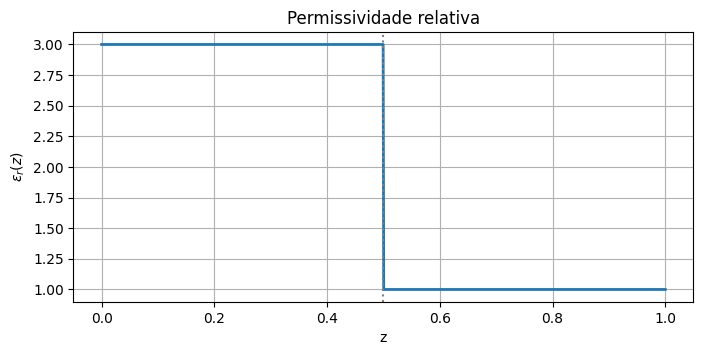

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros do problema
L = 1.0
Va = 10.0
Vb = 0.0

# usar número ímpar de nós para ter nó em z = L/2
n_nodes = 15
if n_nodes % 2 == 0:
    raise ValueError("Use n_nodes ímpar para ter um nó na interface z=L/2.")

z = np.linspace(0.0, L, n_nodes)
h = z[1] - z[0]
n_elem = n_nodes - 1

# conferindo se a interface está na malha
print("Nó central =", z[n_nodes // 2])

# Permissividade relativa
def eps_r(x):
    return 3.0 if x < L/2 else 1.0

# Solução analítica
def phi_exact(x):
    x = np.asarray(x)
    return np.where(x <= 0.5, 10.0 - 5.0*x, 15.0 - 15.0*x)

# FEM
K_fem = np.zeros((n_nodes, n_nodes))
F_fem = np.zeros(n_nodes)

for e in range(n_elem):
    zL = z[e]
    zR = z[e+1]
    ze_mid = 0.5 * (zL + zR)
    eps_e = eps_r(ze_mid)

    ke = (eps_e / h) * np.array([[1.0, -1.0],
                                 [-1.0,  1.0]])

    K_fem[e:e+2, e:e+2] += ke

# sistema reduzido (Dirichlet nas duas extremidades)
K_red = K_fem[1:-1, 1:-1].copy()
F_red = F_fem[1:-1].copy()

F_red -= K_fem[1:-1, 0] * Va
F_red -= K_fem[1:-1, -1] * Vb

phi_fem = np.zeros(n_nodes)
phi_fem[0] = Va
phi_fem[-1] = Vb
phi_fem[1:-1] = np.linalg.solve(K_red, F_red)

# FDM conservativo
eps_half = np.array([eps_r(0.5*(z[i] + z[i+1])) for i in range(n_elem)])

N = n_nodes - 2
A_fdm = np.zeros((N, N))
b_fdm = np.zeros(N)

for i in range(1, n_nodes - 1):
    row = i - 1
    eps_m = eps_half[i - 1]   # eps_{i-1/2}
    eps_p = eps_half[i]       # eps_{i+1/2}

    # diagonal principal
    A_fdm[row, row] = (eps_m + eps_p) / h**2

    # vizinho à esquerda
    if row - 1 >= 0:
        A_fdm[row, row - 1] = -eps_m / h**2
    else:
        b_fdm[row] += eps_m / h**2 * Va

    # vizinho à direita
    if row + 1 < N:
        A_fdm[row, row + 1] = -eps_p / h**2
    else:
        b_fdm[row] += eps_p / h**2 * Vb

phi_fdm = np.zeros(n_nodes)
phi_fdm[0] = Va
phi_fdm[-1] = Vb
phi_fdm[1:-1] = np.linalg.solve(A_fdm, b_fdm)

# Solução exata nos nós
phi_ex = phi_exact(z)

# Erros
err_fem_exact = np.max(np.abs(phi_fem - phi_ex))
err_fdm_exact = np.max(np.abs(phi_fdm - phi_ex))
err_fem_fdm = np.max(np.abs(phi_fem - phi_fdm))

print("\nErro máximo FEM vs exata =", err_fem_exact)
print("Erro máximo FDM vs exata =", err_fdm_exact)
print("Erro máximo FEM vs FDM   =", err_fem_fdm)

# Gráficos
z_dense = np.linspace(0.0, L, 1000)

plt.figure(figsize=(8, 5))
plt.plot(z_dense, phi_exact(z_dense), 'k-', linewidth=2, label='Solução exata')
plt.plot(z, phi_fem, 'ro-', label='FEM')
plt.plot(z, phi_fdm, 'bs--', label='FDM')
plt.axvline(L/2, color='gray', linestyle=':', label='Interface z=L/2')
plt.xlabel('z')
plt.ylabel(r'$\phi(z)$')
plt.title('Capacitor com dois dielétricos: FEM x FDM x solução exata')
plt.grid(True)
plt.legend()
plt.show()

# gráfico da permissividade
eps_plot = np.array([eps_r(zz) for zz in z_dense])

plt.figure(figsize=(8, 3.5))
plt.plot(z_dense, eps_plot, linewidth=2)
plt.axvline(L/2, color='gray', linestyle=':')
plt.xlabel('z')
plt.ylabel(r'$\varepsilon_r(z)$')
plt.title('Permissividade relativa')
plt.grid(True)
plt.show()